# Wavelet Transform: Time-Frequency Localization

This notebook explains **why wavelets are localized in both time and frequency**, how that differs from the Fourier transform, and how the same idea appears in the **2D DWT** used by the DCT-based image fusion project.

References: [Wikipedia — Wavelet transform](https://en.wikipedia.org/wiki/Wavelet_transform)
---

## 1. Introduction

Real-world signals are often **non-stationary**: their frequency content changes over time. Examples include heart rhythms, speech, seismic recordings, and images with edges at different locations.

The **Fourier transform** decomposes a signal into global sinusoids. It tells us *which* frequencies are present, but not *when* they occur.

### 1.1 Integral wavelet transform (CWT)

A **wavelet** is a short, oscillating function localized in time. The **continuous wavelet transform** convolves the signal with scaled, translated copies of a mother wavelet $\psi(t)$:

$$W_\psi f(a, b) = \frac{1}{\sqrt{|a|}}\int_{-\infty}^{\infty} {\psi\!\left(\frac{t - b}{a}\right)}\, f(t)\, dt$$

| Parameter | Role |
|-----------|------|
| $a$ | **scale** — large $a$: low frequency; small $a$: high frequency |
| $b$ | **translation** — where in time we analyze |
| $\psi$ | **mother wavelet** — shape stays fixed; only scale and position change |

The basis function can be viewed as the **impulse response** of a band-pass filter whose bandwidth changes with scale.

### 1.2 Orthonormal wavelets and the DWT (discrete case)

For the **discrete wavelet transform**, Wikipedia defines an orthonormal basis built by **dyadic dilation and translation**:

$$\psi_{jk}(x) = 2^{j/2}\,\psi(2^j x - k), \quad j, k \in \mathbb{Z}$$

Any square-integrable signal can be expanded as a **wavelet series**:

$$f(x) = \sum_{j,k} c_{jk}\,\psi_{jk}(x)$$

The discrete coefficients are samples of the CWT at dyadic scales: $c_{jk} = W_\psi f(2^{-j},\, k \cdot 2^{-j})$, where $a = 2^{-j}$ is the **binary dilation** and $b = k \cdot 2^{-j}$ is the **dyadic position**.

Sections 2–7 use **1D signals** for intuition. Section 8 extends the idea to **2D images** and the fusion project's DWT baseline.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.fft import fft, fftfreq
from scipy import signal
import pywt
import cv2

plt.rcParams.update({
    "figure.figsize": (12, 4),
    "figure.dpi": 100,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

NOTEBOOK_DIR = Path.cwd()
FUSION_IMAGES = NOTEBOOK_DIR.parent / "Images"
SAMPLE_IMAGE = FUSION_IMAGES / "DSC01299.jpg"

FS = 1000  # sampling rate [Hz]
DURATION = 1.0
t = np.linspace(0, DURATION, int(FS * DURATION), endpoint=False)

CWT_WAVELET = "cmor3.0-1.0"  # complex Morlet (format: cmor{B}-{C}; B must be > 0, e.g. 3.0)

# Demo tones — far apart in frequency so CWT vs STFT differences are easy to see
FREQ_LOW = 5       # Hz — slow sine (period 200 ms)
FREQ_HIGH = 120    # Hz — fast sine (period 8 ms); ~24× higher than FREQ_LOW
SWITCH_TIME = 0.5  # s — non-stationary signal switches here

# Scalogram resolution — tune here (or pass overrides to plot_cwt_scalogram)
SCALOGRAM_FREQ_MIN = 3       # Hz — lower bound of frequency grid
SCALOGRAM_FREQ_MAX = 150     # Hz — upper bound of frequency grid
SCALOGRAM_NUM_FREQS = 200    # ↑ finer frequency bins (slower CWT)


def cwt_wavelet_shape(wavelet_name, scale, half_width=None, min_points=201):
    """Plot-friendly wavelet shape at a given scale (avoids CWT edge artifacts).

    At small scales the default integer grid undersamples oscillations; we
    upsample internally so low-scale plots stay smooth (scale in CWT is
    multiplied by the same factor).
    """
    if half_width is None:
        half_width = int(4 * scale + 1)

    n_coarse = 2 * half_width + 1
    upsample = max(1, int(np.ceil(min_points / n_coarse)))
    half_width_fine = half_width * upsample
    scale_fine = scale * upsample

    pad = max(512 * upsample, 8 * scale_fine + half_width_fine)
    impulse = np.zeros(2 * pad + 1)
    impulse[pad] = 1.0
    coeffs, _ = pywt.cwt(impulse, [scale_fine], wavelet_name)
    w = np.real(coeffs[0])[pad - half_width_fine: pad + half_width_fine + 1]
    t = np.arange(-half_width_fine, half_width_fine + 1) / upsample
    w = w / (np.max(np.abs(w)) + 1e-12)
    return t, w


def compute_cwt_scalogram(
    sig, wavelet=CWT_WAVELET, freq_min=5, freq_max=100, num_freqs=100,
):
    """CWT power vs time and frequency (reflect-padded, frequency-targeted scales)."""
    n = len(sig)
    pad = n // 2
    sig_pad = np.pad(sig, pad, mode="reflect")

    freqs_hz = np.logspace(np.log10(freq_min), np.log10(freq_max), num_freqs)
    scales = pywt.frequency2scale(wavelet, freqs_hz / FS)
    coefficients, _ = pywt.cwt(sig_pad, scales, wavelet, sampling_period=1 / FS)
    power = np.abs(coefficients)[:, pad: pad + n]
    return freqs_hz, power


def plot_scalogram_axis(
    ax, t_axis, freqs_hz, power,
    title="CWT scalogram (time-frequency)",
    freq_min=None, freq_max=None, cmap="jet", log_y=True,
    ref_freqs=(),
):
    """Plot scalogram: pcolormesh(t, frequencies, power, shading='gouraud')."""
    order = np.argsort(freqs_hz)
    freqs_plot = freqs_hz[order]
    power_plot = power[order, :]

    if freq_min is not None:
        keep = freqs_plot >= freq_min
        freqs_plot, power_plot = freqs_plot[keep], power_plot[keep, :]
    if freq_max is not None:
        keep = freqs_plot <= freq_max
        freqs_plot, power_plot = freqs_plot[keep], power_plot[keep, :]

    vmax = np.percentile(power_plot, 98)
    im = ax.pcolormesh(
        t_axis, freqs_plot, power_plot,
        shading="gouraud", cmap=cmap, vmin=0, vmax=vmax,
    )
    ax.set_title(title)
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Frequency [Hz]")
    if log_y:
        ax.set_yscale("log")
    if freq_min is not None or freq_max is not None:
        ax.set_ylim(freq_min or freqs_plot.min(), freq_max or freqs_plot.max())
    for f_ref in ref_freqs:
        ax.axhline(f_ref, color="white", ls="--", lw=0.8, alpha=0.8)
    return im


def plot_cwt_vs_stft(
    sig,
    t_axis,
    freq_min=None,
    freq_max=None,
    nperseg=256,
    switch_time=SWITCH_TIME,
    ref_freqs=(FREQ_LOW, FREQ_HIGH),
):
    """Side-by-side CWT vs STFT with signal on top — highlights adaptive vs fixed window."""
    freq_min = SCALOGRAM_FREQ_MIN if freq_min is None else freq_min
    freq_max = SCALOGRAM_FREQ_MAX if freq_max is None else freq_max

    cwt_freqs, cwt_power = compute_cwt_scalogram(
        sig,
        freq_min=freq_min,
        freq_max=freq_max,
        num_freqs=SCALOGRAM_NUM_FREQS,
    )
    stft_freqs, stft_times, stft_power = signal.spectrogram(
        sig, fs=FS, nperseg=nperseg, noverlap=nperseg * 3 // 4,
    )
    stft_keep = (stft_freqs >= freq_min) & (stft_freqs <= freq_max)

    fig = plt.figure(figsize=(14, 8))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 2.2], hspace=0.35, wspace=0.25)
    ax_sig = fig.add_subplot(gs[0, :])
    ax_cwt = fig.add_subplot(gs[1, 0])
    ax_stft = fig.add_subplot(gs[1, 1])

    ax_sig.plot(t_axis, sig, color="C1")
    ax_sig.axvline(switch_time, color="gray", ls="--", alpha=0.7)
    ax_sig.set_title(
        f"Non-stationary demo: {FREQ_LOW} Hz (t < {switch_time} s) → "
        f"{FREQ_HIGH} Hz (t ≥ {switch_time} s)"
    )
    ax_sig.set_xlabel("Time [s]")
    ax_sig.set_ylabel("Amplitude")
    ax_sig.set_xlim(t_axis[0], t_axis[-1])

    im0 = plot_scalogram_axis(
        ax_cwt, t_axis, cwt_freqs, cwt_power,
        title="CWT — adaptive window per scale",
        freq_min=freq_min, freq_max=freq_max, ref_freqs=ref_freqs,
    )
    plt.colorbar(im0, ax=ax_cwt, label="|coefficient|")

    stft_vmax = np.percentile(stft_power[stft_keep], 98)
    im1 = ax_stft.pcolormesh(
        stft_times, stft_freqs[stft_keep], stft_power[stft_keep],
        shading="gouraud", cmap="jet", vmin=0, vmax=stft_vmax,
    )
    ax_stft.set_yscale("log")
    ax_stft.set_title(f"STFT — fixed window ({nperseg} samples = {nperseg / FS * 1000:.0f} ms)")
    ax_stft.set_xlabel("Time [s]")
    ax_stft.set_ylabel("Frequency [Hz]")
    ax_stft.set_ylim(freq_min, freq_max)
    for f_ref in ref_freqs:
        ax_stft.axhline(f_ref, color="white", ls="--", lw=0.8, alpha=0.8)
    plt.colorbar(im1, ax=ax_stft, label="power")

    fig.suptitle(
        f"CWT vs STFT — tones {FREQ_LOW} Hz and {FREQ_HIGH} Hz are far apart "
        f"({FREQ_HIGH / FREQ_LOW:.0f}× ratio)",
        y=1.01,
    )
    plt.tight_layout()
    plt.show()

    print(f"CWT: narrow time support at {FREQ_HIGH} Hz, narrow freq support at {FREQ_LOW} Hz.")
    print(
        f"STFT: one {nperseg / FS * 1000:.0f} ms window for all frequencies — "
        "low band smears in frequency OR the switch smears in time (not both)."
    )

## 2. Principle: Adaptive Time–Frequency Resolution

Following [Wikipedia's Principle section](https://en.wikipedia.org/wiki/Wavelet_transform#Principle), wavelet analysis obeys the **uncertainty principle** of signal processing:

$$\Delta t \cdot \Delta\omega \geq \frac{1}{2}$$

where $\Delta t$ is the time extent of the analysis window and $\Delta\omega$ is the frequency uncertainty ($\omega = 2\pi f$). You cannot have perfect resolution in both domains at once.

**Wavelets adapt the window to the frequency being analyzed** (unlike the FFT, which uses infinite sinusoids, or the STFT, which uses one fixed window for all frequencies):

| Analysis window $\Delta t$ | Time resolution | Frequency resolution | Typical use |
|---------------------------|-----------------|----------------------|-------------|
| **Large** (large scale $a$) | Poor | Good | Low frequencies, slow trends |
| **Small** (small scale $a$) | Good | Poor | High frequencies, transients |

> *"Wavelet transformation is good in time resolution of high frequencies, while for slowly varying functions, the frequency resolution is remarkable."* — [Wikipedia](https://en.wikipedia.org/wiki/Wavelet_transform#Principle)

The plot below shows the same Morlet wavelet at three scales: small scale = short window (local events); large scale = wide window (global low-frequency structure).

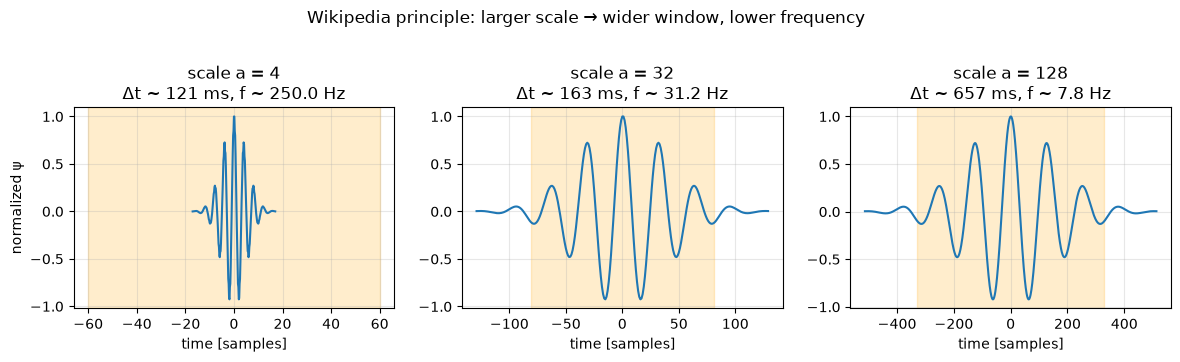

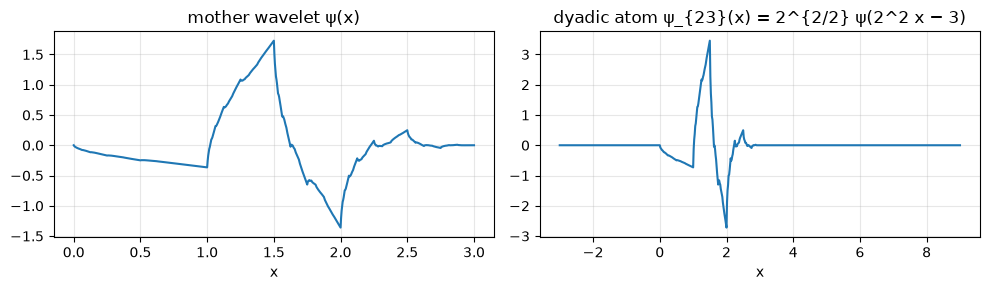

In [2]:
def wavelet_support_width(w, threshold=0.1):
    """Approximate time support where |w| exceeds threshold * max."""
    idx = np.where(np.abs(w) >= threshold * np.max(np.abs(w)))[0]
    return (idx[-1] - idx[0]) if len(idx) else 0


scales_demo = [4, 32, 128]
fig, axes = plt.subplots(1, len(scales_demo), figsize=(12, 3.5))

for ax, scale in zip(axes, scales_demo):
    t_w, w = cwt_wavelet_shape(CWT_WAVELET, scale)
    dt_samples = wavelet_support_width(w)
    freq_hz = pywt.scale2frequency(CWT_WAVELET, scale) * FS

    ax.plot(t_w, w, color="C0")
    half_dt = dt_samples // 2
    ax.axvspan(-half_dt, half_dt, alpha=0.2, color="orange")
    ax.set_title(
        f"scale a = {scale}\n"
        f"Δt ~ {dt_samples / FS * 1000:.0f} ms, f ~ {freq_hz:.1f} Hz"
    )
    ax.set_xlabel("time [samples]")

axes[0].set_ylabel("normalized ψ")
fig.suptitle("Wikipedia principle: larger scale → wider window, lower frequency", y=1.02)
plt.tight_layout()
plt.show()

# Dyadic discrete wavelets: psi_{jk}(x) = 2^{j/2} psi(2^j x - k)
wavelet = pywt.Wavelet("db2")
_, psi, x = wavelet.wavefun(level=8)
j, k = 2, 3
scale_factor = 2 ** j
x_shifted = scale_factor * x - k
psi_jk = (scale_factor ** 0.5) * np.interp(x_shifted, x, psi, left=0, right=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(x, psi)
axes[0].set_title("mother wavelet ψ(x)")
axes[0].set_xlabel("x")
axes[1].plot(x_shifted, psi_jk)
axes[1].set_title(f"dyadic atom ψ_{{{j}{k}}}(x) = 2^{{{j}/2}} ψ(2^{j} x − {k})")
axes[1].set_xlabel("x")
plt.tight_layout()
plt.show()

## 3. Fourier Transform Baseline

### 3A — Stationary signal (sum of two sines)

Two sine waves at **5 Hz** and **120 Hz** (far apart — a slow and a fast tone), present for the entire duration. The FFT correctly identifies both frequencies.

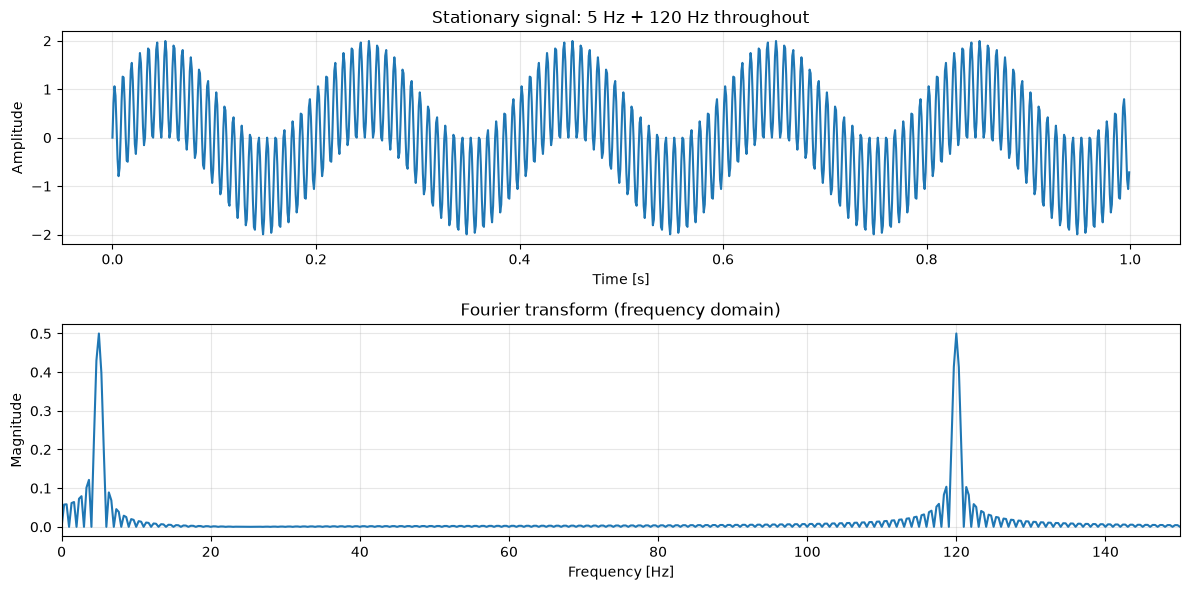

Takeaway: FFT finds which frequencies exist, but not when they occur.


In [3]:
stationary = (
    np.sin(2 * np.pi * FREQ_LOW * t)
    + np.sin(2 * np.pi * FREQ_HIGH * t)
)
padded = 3 * len(t)
freqs = fftfreq(padded, d=1 / FS)
spectrum = np.abs(fft(stationary, padded)) / len(t)
pos = freqs >= 0

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(t, stationary)
axes[0].set_title(f"Stationary signal: {FREQ_LOW} Hz + {FREQ_HIGH} Hz throughout")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Amplitude")

axes[1].plot(freqs[pos], spectrum[pos])
axes[1].set_title("Fourier transform (frequency domain)")
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel("Magnitude")
axes[1].set_xlim(0, SCALOGRAM_FREQ_MAX)
plt.tight_layout()
plt.show()

print("Takeaway: FFT finds which frequencies exist, but not when they occur.")

### 3B — Non-stationary signal (frequency switch)

**5 Hz** for the first half, **120 Hz** for the second half — the same two tones as in 3A, but only one is active at a time. The FFT still shows both peaks, but **hides when each frequency is active**.

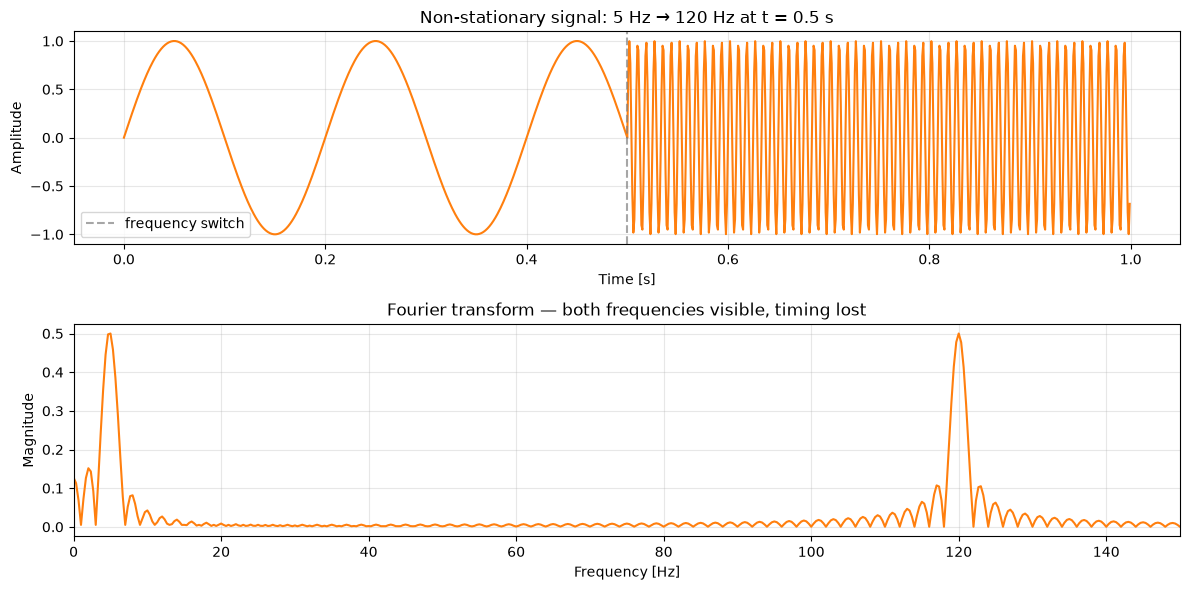

Takeaway: FFT cannot tell us that 5 Hz appears first and 120 Hz second.


In [4]:
nonstationary = np.where(
    t < SWITCH_TIME,
    np.sin(2 * np.pi * FREQ_LOW * t),
    np.sin(2 * np.pi * FREQ_HIGH * t),
)

spectrum_ns = np.abs(fft(nonstationary, padded)) / len(t) * 2

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(t, nonstationary, color="C1")
axes[0].axvline(SWITCH_TIME, color="gray", ls="--", alpha=0.7, label="frequency switch")
axes[0].set_title(
    f"Non-stationary signal: {FREQ_LOW} Hz → {FREQ_HIGH} Hz at t = {SWITCH_TIME} s"
)
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Amplitude")
axes[0].legend()

axes[1].plot(freqs[pos], spectrum_ns[pos], color="C1")
axes[1].set_title("Fourier transform — both frequencies visible, timing lost")
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel("Magnitude")
axes[1].set_xlim(0, SCALOGRAM_FREQ_MAX)
plt.tight_layout()
plt.show()

print(
    f"Takeaway: FFT cannot tell us that {FREQ_LOW} Hz appears first "
    f"and {FREQ_HIGH} Hz second."
)

## 4. Mother Wavelets and Localization

Unlike sinusoids (infinite support), wavelets have **finite extent in time**. Scaling changes both their width and effective frequency:

- **Small scale** → narrow in time, sensitive to high frequencies
- **Large scale** → wide in time, sensitive to low frequencies

Below we visualize several mother wavelets. The fusion project uses discrete wavelets `db1`, `db2`, and `sym4`; for CWT we use Morlet (`cmor`) and Mexican hat (`mexh`).

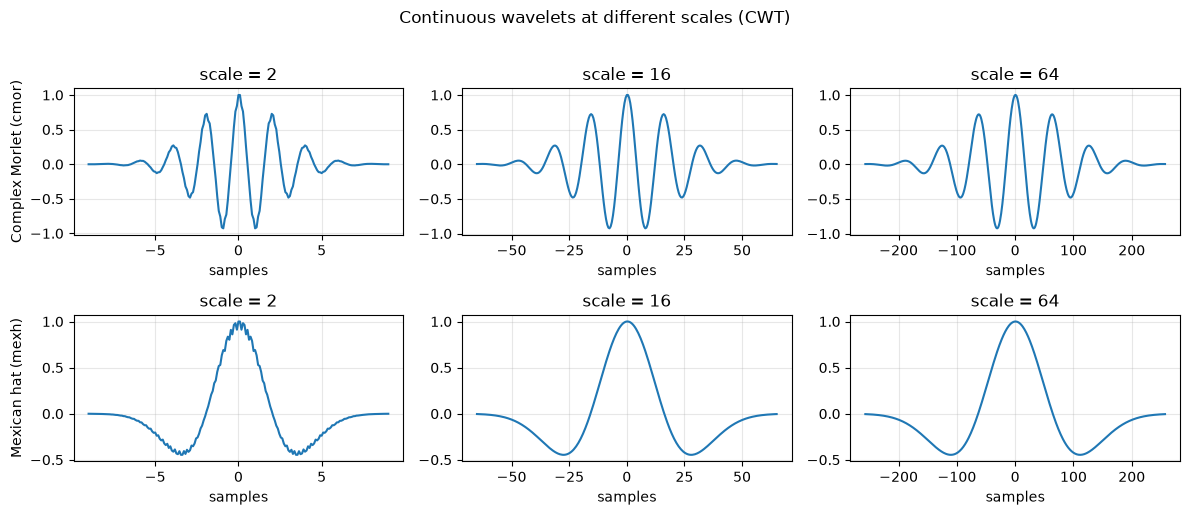

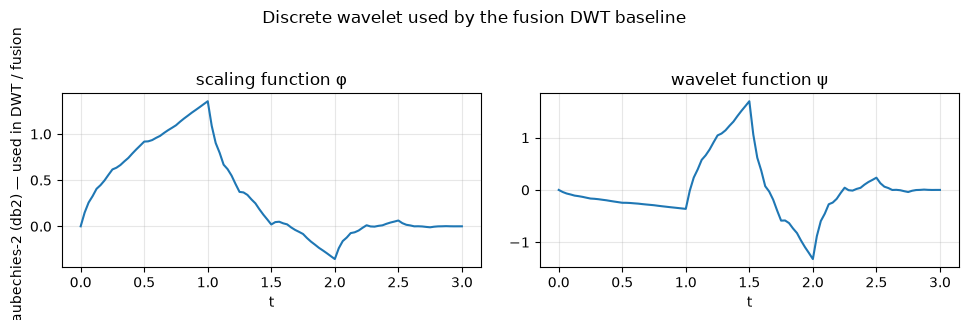

In [5]:
def plot_cwt_wavelet_at_scales(wavelet_name, scales, title, ax_row):
    """Plot a continuous wavelet at different scales."""
    for col, scale in enumerate(scales):
        t_w, w = cwt_wavelet_shape(wavelet_name, scale)
        ax_row[col].plot(t_w, w)
        ax_row[col].set_title(f"scale = {scale}")
        ax_row[col].set_xlabel("samples")
    ax_row[0].set_ylabel(title)


def plot_discrete_wavelet(wavelet_name, title, ax_row):
    """Plot discrete wavelet (db2) via wavefun — used in DWT, not CWT."""
    wavelet = pywt.Wavelet(wavelet_name)
    phi, psi, x = wavelet.wavefun(level=5)
    ax_row[0].plot(x, phi)
    ax_row[0].set_title("scaling function φ")
    ax_row[1].plot(x, psi)
    ax_row[1].set_title("wavelet function ψ")
    for ax in ax_row:
        ax.set_xlabel("t")
    ax_row[0].set_ylabel(title)


scales = [2, 16, 64]
cwt_wavelets = [
    (CWT_WAVELET, "Complex Morlet (cmor)"),
    ("mexh", "Mexican hat (mexh)"),
]

fig, axes = plt.subplots(len(cwt_wavelets), len(scales), figsize=(12, 5))
for row, (wname, label) in enumerate(cwt_wavelets):
    plot_cwt_wavelet_at_scales(wname, scales, label, axes[row])
fig.suptitle("Continuous wavelets at different scales (CWT)", y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
plot_discrete_wavelet("db2", "Daubechies-2 (db2) — used in DWT / fusion", axes)
fig.suptitle("Discrete wavelet used by the fusion DWT baseline", y=1.05)
plt.tight_layout()
plt.show()

## 5. Continuous Wavelet Transform (CWT)

The CWT produces a **scalogram**: magnitude of coefficients as a function of time and frequency. Bright regions indicate where a frequency band is active.

We use **log-spaced frequency bins** and a **log y-axis** so the low (5 Hz) and high (120 Hz) bands are both visible on the same plot.

We apply CWT to the **non-stationary** signal from Section 3B.

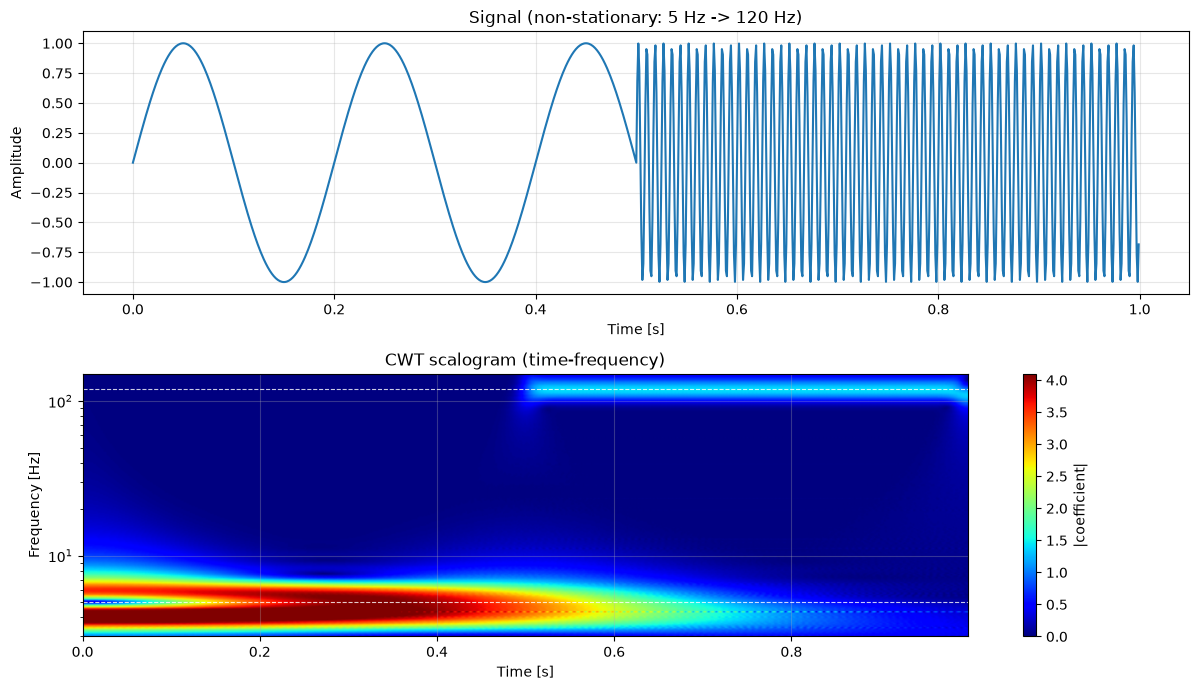

In [6]:
def plot_cwt_scalogram(
    sig, t_axis, wavelet=CWT_WAVELET, title_suffix="",
    freq_min=None, freq_max=None, num_freqs=None, figsize=(12, 7),
):
    """Plot signal + CWT scalogram. Override freq_min/freq_max/num_freqs or set SCALOGRAM_* globals."""
    freq_min = SCALOGRAM_FREQ_MIN if freq_min is None else freq_min
    freq_max = SCALOGRAM_FREQ_MAX if freq_max is None else freq_max
    num_freqs = SCALOGRAM_NUM_FREQS if num_freqs is None else num_freqs

    freqs_hz, power = compute_cwt_scalogram(
        sig, wavelet=wavelet,
        freq_min=freq_min, freq_max=freq_max, num_freqs=num_freqs,
    )

    fig, axes = plt.subplots(2, 1, figsize=figsize)
    axes[0].plot(t_axis, sig)
    axes[0].set_title(f"Signal{title_suffix}")
    axes[0].set_xlabel("Time [s]")
    axes[0].set_ylabel("Amplitude")

    im = plot_scalogram_axis(
        axes[1], t_axis, freqs_hz, power,
        freq_min=freq_min, freq_max=freq_max,
        ref_freqs=(FREQ_LOW, FREQ_HIGH),
    )
    plt.colorbar(im, ax=axes[1], label="|coefficient|")
    plt.tight_layout()
    plt.show()


plot_cwt_scalogram(
    nonstationary, t,
    title_suffix=f" (non-stationary: {FREQ_LOW} Hz -> {FREQ_HIGH} Hz)",
)

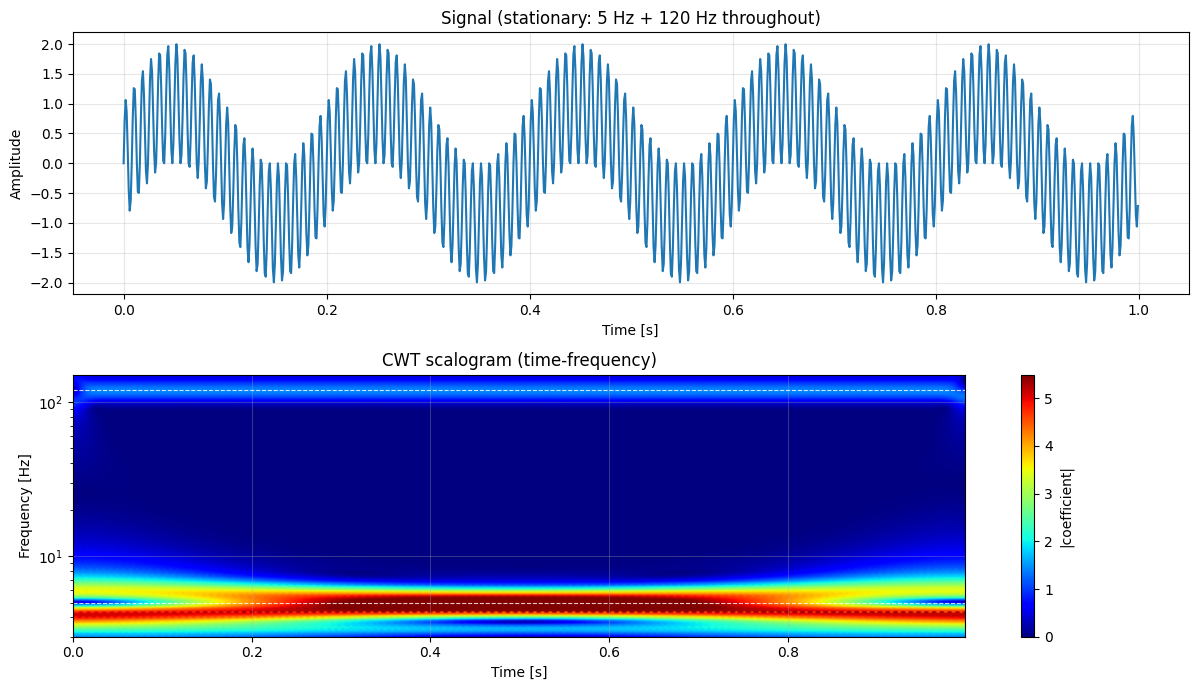

Contrast: stationary signal shows both bands across all time; non-stationary shows 5 Hz only before t=0.5 s and 120 Hz only after.


In [7]:
plot_cwt_scalogram(
    stationary, t,
    title_suffix=f" (stationary: {FREQ_LOW} Hz + {FREQ_HIGH} Hz throughout)",
)
print(
    f"Contrast: stationary signal shows both bands across all time; "
    f"non-stationary shows {FREQ_LOW} Hz only before t={SWITCH_TIME} s "
    f"and {FREQ_HIGH} Hz only after."
)

## 6. CWT vs STFT Spectrogram

A **short-time Fourier transform (STFT)** also gives a time–frequency plot, but uses a **fixed window** for all frequencies. That means a constant trade-off between time and frequency resolution.

The CWT uses a **variable window** per scale — better when low and high frequencies are **far apart** (here: 5 Hz vs 120 Hz, a ~24× ratio):

| | **5 Hz band** (slow, wide cycles) | **120 Hz band** (fast, short cycles) |
|---|-----------------------------------|--------------------------------------|
| **CWT** | wide wavelet → good frequency resolution | narrow wavelet → good time resolution |
| **STFT** | same 256 ms window → low band smears in frequency | same window → switch at t = 0.5 s smears in time |

Dashed white lines mark the true tone frequencies. On the **log y-axis**, the two bands sit far apart — making the adaptive vs fixed-window difference easy to see.

### Transform comparison ([Wikipedia](https://en.wikipedia.org/wiki/Wavelet_transform#Comparison_with_Fourier_transform_and_time-frequency_analysis))

| Transform | Representation | Domain |
|-----------|----------------|--------|
| **Fourier** | $\hat{X}(f) = \int x(t)\, e^{-i 2\pi f t}\, dt$ | frequency only |
| **Time–frequency (STFT)** | $X(t, f)$ | time + frequency (fixed window) |
| **Wavelet (CWT)** | $X(a, b) = \frac{1}{\sqrt{a}} \int \overline{\psi\!\left(\frac{t-b}{a}\right)} x(t)\, dt$ | scale + time shift (adaptive window) |

C:\Users\rosmanov\AppData\Local\Temp\ipykernel_31816\1609677758.py:178: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


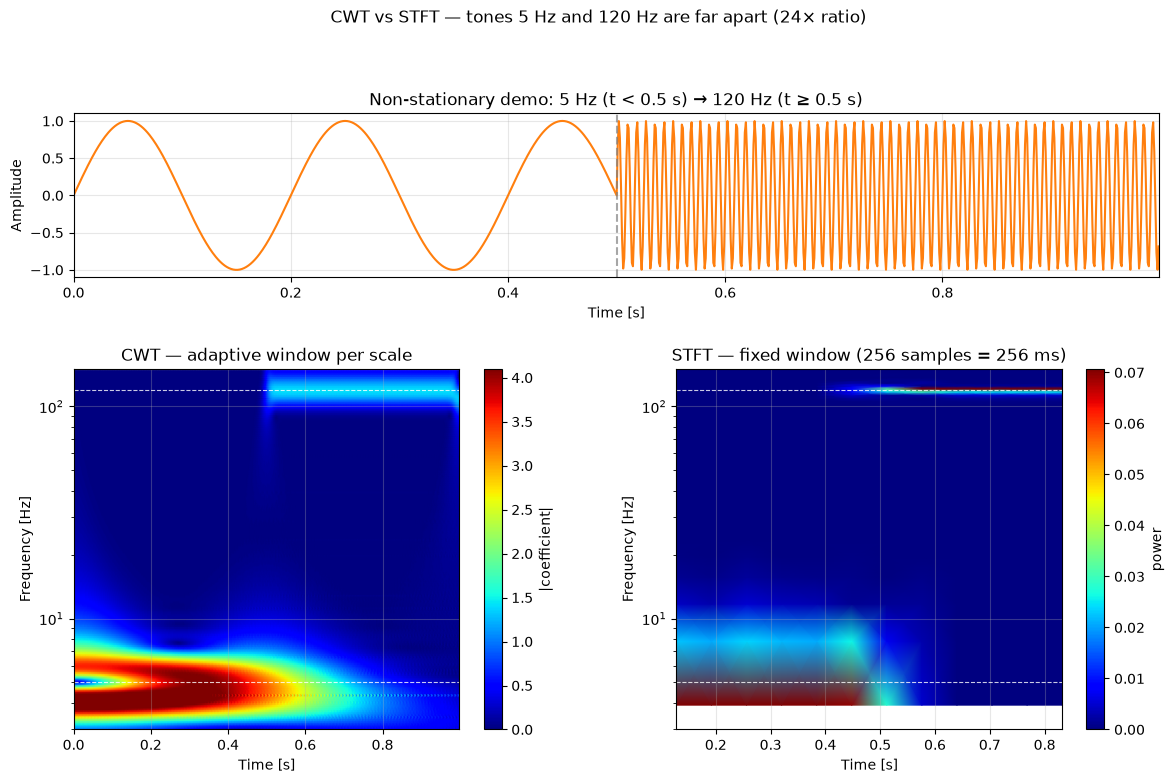

CWT: narrow time support at 120 Hz, narrow freq support at 5 Hz.
STFT: one 256 ms window for all frequencies — low band smears in frequency OR the switch smears in time (not both).


In [7]:
plot_cwt_vs_stft(nonstationary, t)

## 7. Discrete Wavelet Transform (1D DWT)

The **DWT** uses **dyadic scales** ($a = 2^{-j}$) and is **efficient** — no redundancy. Each level splits the signal into:
- **Approximation** $cA$ (low frequency)
- **Detail** $cD$ (high frequency)

Coefficients $c_{jk}$ remain indexed by time ($k$) and scale ($j$), so localization is preserved. This is the discrete version of the wavelet series from Section 1.2.

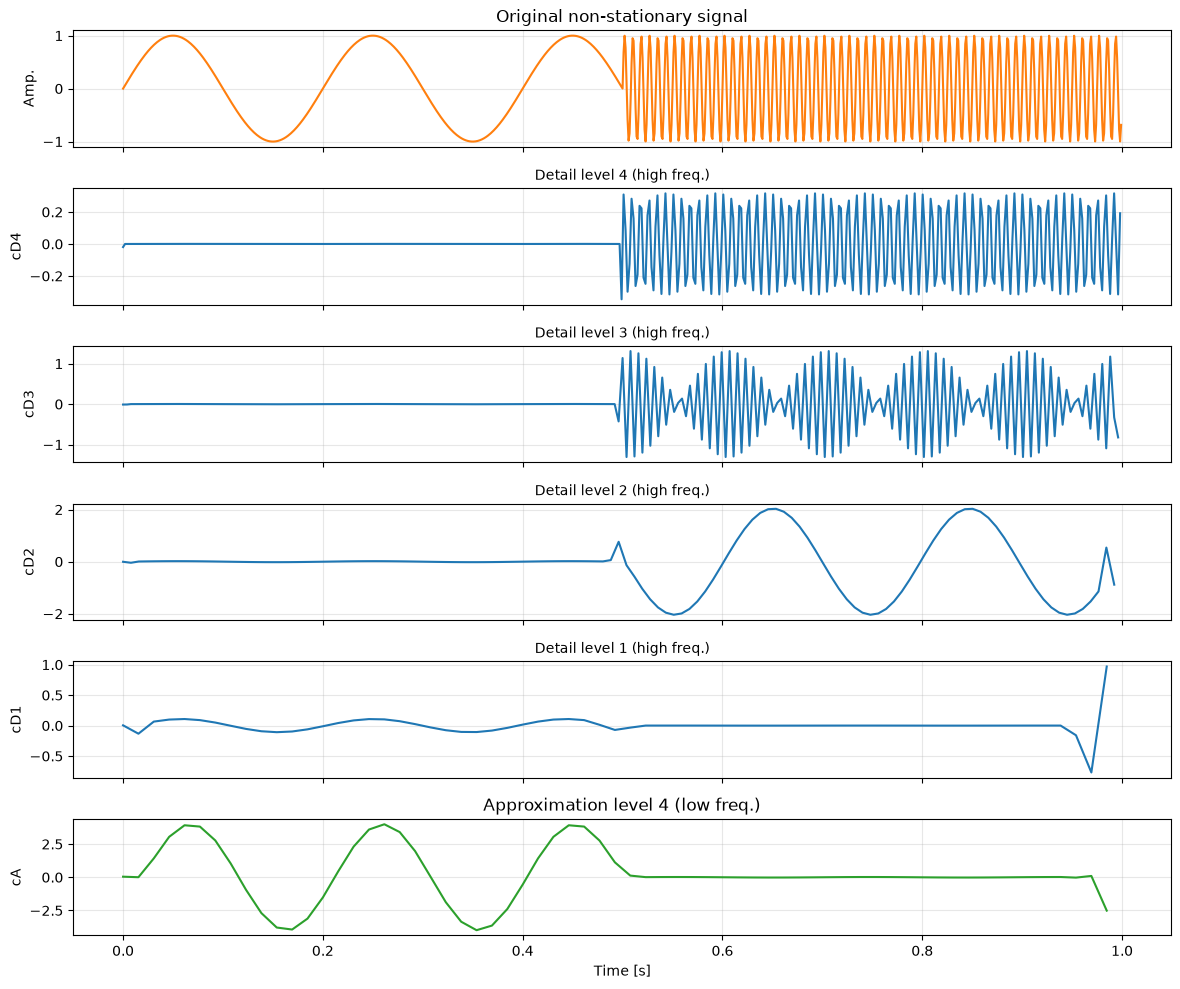

In [8]:
wavelet_1d = "db2"
level = 4
coeffs = pywt.wavedec(nonstationary, wavelet_1d, level=level)

fig, axes = plt.subplots(level + 2, 1, figsize=(12, 10), sharex=True)
axes[0].plot(t, nonstationary, color="C1")
axes[0].set_title("Original non-stationary signal")
axes[0].set_ylabel("Amp.")

for i in range(level):
    detail = coeffs[-(i + 1)]
    t_detail = np.linspace(0, DURATION, len(detail), endpoint=False)
    axes[i + 1].plot(t_detail, detail)
    axes[i + 1].set_ylabel(f"cD{level - i}")
    axes[i + 1].set_title(f"Detail level {level - i} (high freq.)", fontsize=10)

approx = coeffs[0]
t_approx = np.linspace(0, DURATION, len(approx), endpoint=False)
axes[-1].plot(t_approx, approx, color="C2")
axes[-1].set_ylabel("cA")
axes[-1].set_title(f"Approximation level {level} (low freq.)")
axes[-1].set_xlabel("Time [s]")
plt.tight_layout()
plt.show()

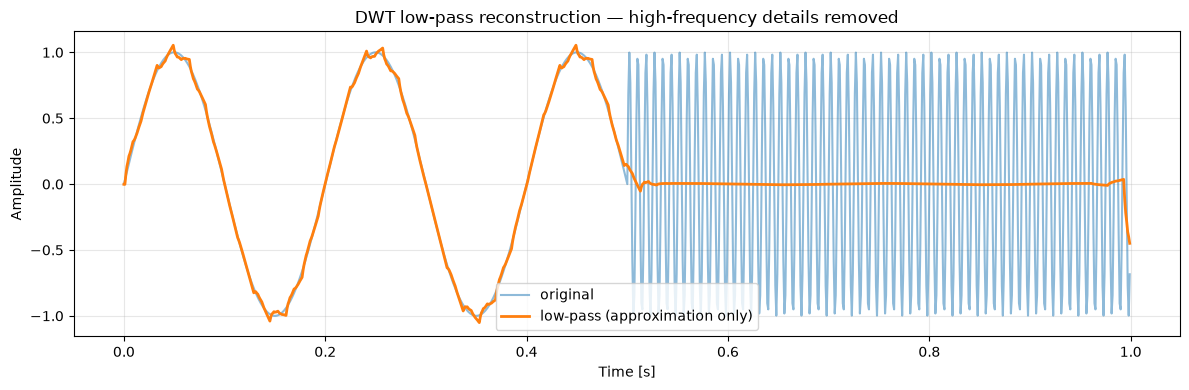

In [9]:
# Reconstruction demo: keep only low-frequency approximation
coeffs_lowpass = [coeffs[0]] + [np.zeros_like(c) for c in coeffs[1:]]
reconstructed = pywt.waverec(coeffs_lowpass, wavelet_1d)
reconstructed = reconstructed[: len(nonstationary)]

plt.figure(figsize=(12, 4))
plt.plot(t, nonstationary, alpha=0.5, label="original")
plt.plot(t, reconstructed, lw=2, label="low-pass (approximation only)")
plt.title("DWT low-pass reconstruction — high-frequency details removed")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()

### 7B. Analysis / synthesis: decomposition, decimation, interpolation, reconstruction

The **discrete wavelet transform** used in compression (e.g. JPEG 2000) follows a **subband coding** pipeline ([Wikipedia — wavelet compression](https://en.wikipedia.org/wiki/Wavelet_transform#Wavelet_compression)):

**Analysis (decomposition):**
1. Convolve the signal with a **low-pass** filter $h_0$ and a **high-pass** filter $h_1$.
2. **Decimate** (downsample) each result by 2 — keep every other sample. Length halves; this is where multiresolution comes from.
3. Feed the low-pass branch into the next level; details $cD$ are stored as coefficients.

**Synthesis (reconstruction):**
1. **Interpolate** (upsample) each subband by inserting zeros between samples.
2. Convolve with **synthesis** filters $g_0$, $g_1$ and add the branches.
3. Repeat from coarsest to finest level — perfect reconstruction when no coefficients are discarded.

**Wavelet compression** applies the DWT, then **quantizes** or discards small coefficients (most energy sits in few large coeffs). The signal is not compressed by the transform itself — compression comes from encoding the sparse coefficients (used in JPEG 2000, DjVu, etc.).

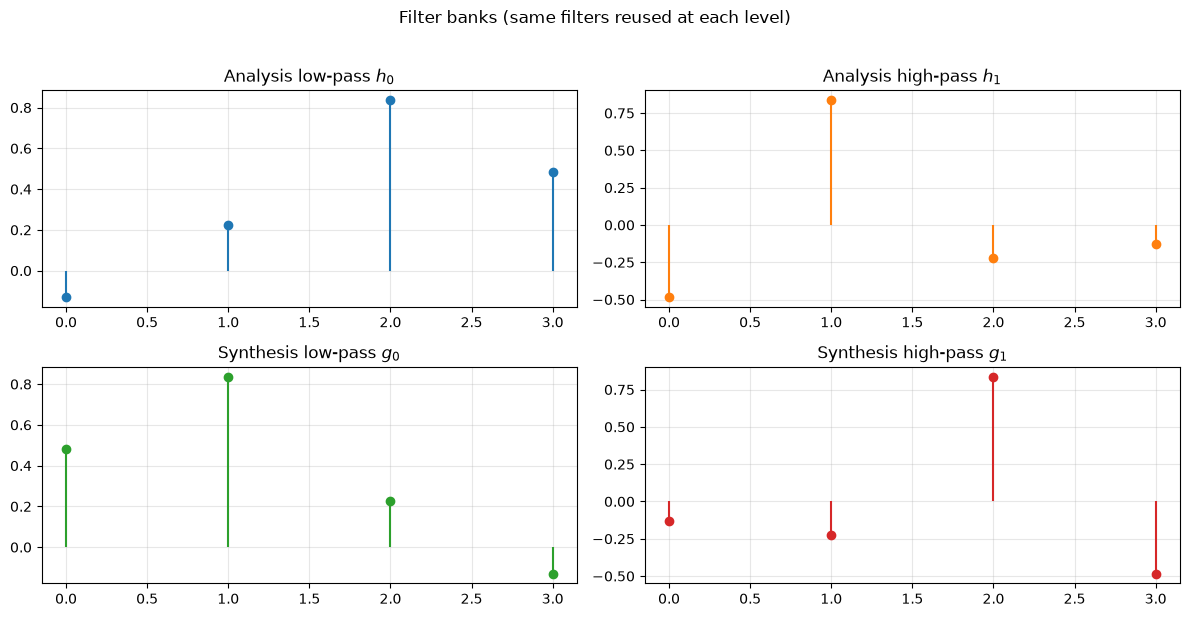

Level 1: 1000 -> cA1: 501, cD1: 501
Level 2: 501 -> cA2: 252, cD2: 252
upfirdn upsample cA1: 501 -> 1002
Perfect reconstruction error (2-level): 6.66e-16


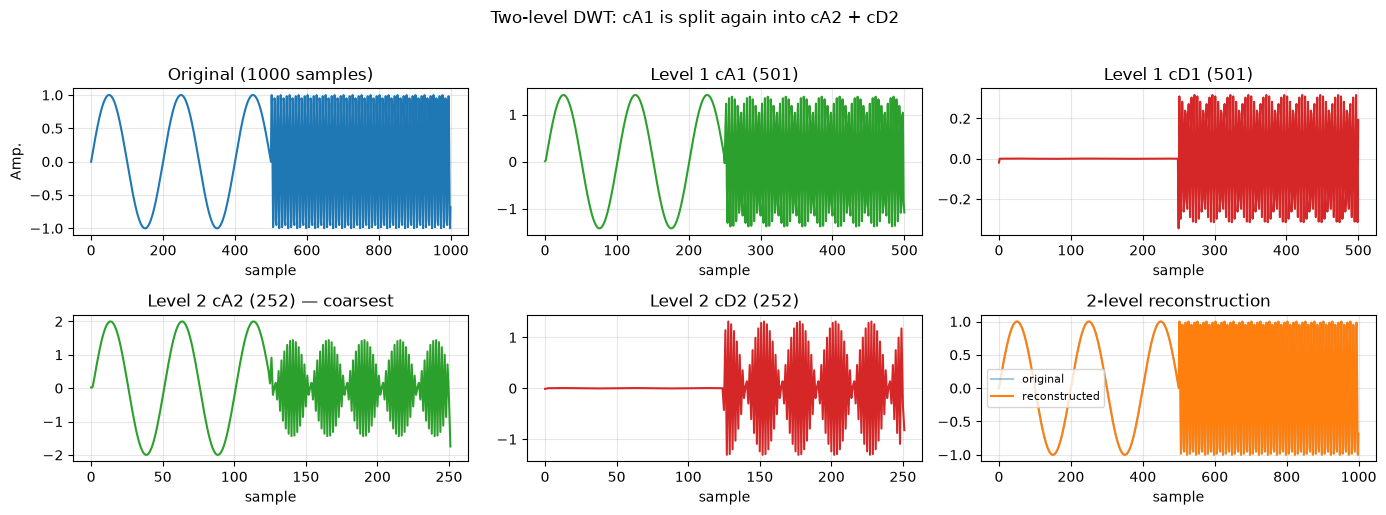

In [10]:
from scipy.signal import upfirdn

wavelet_1d = "db2"
w = pywt.Wavelet(wavelet_1d)
h0, h1 = w.dec_lo, w.dec_hi  # analysis: low-pass, high-pass
g0, g1 = w.rec_lo, w.rec_hi  # synthesis: low-pass, high-pass

sig = nonstationary

# --- Level 1: filter + decimation (pywt.dwt wraps this) ---
cA1, cD1 = pywt.dwt(sig, wavelet_1d, mode="symmetric")

# --- Level 2: decompose approximation only ---
cA2, cD2 = pywt.dwt(cA1, wavelet_1d, mode="symmetric")

# Reconstruct: level 2 → level 1 → full signal (trim to match pywt lengths)
rec_A1 = pywt.idwt(cA2, cD2, wavelet_1d, mode="symmetric")[: len(cA1)]
rec_pywt = pywt.idwt(rec_A1, cD1, wavelet_1d, mode="symmetric")[: len(sig)]

# Interpolation demo: upsample ×2 (scipy order: filter first, signal second)
up_cA1 = upfirdn([1, 0], cA1, up=2)

fig, axes = plt.subplots(2, 2, figsize=(12, 6))

axes[0, 0].stem(h0, linefmt="C0-", markerfmt="C0o", basefmt=" ")
axes[0, 0].set_title("Analysis low-pass $h_0$")
axes[0, 1].stem(h1, linefmt="C1-", markerfmt="C1o", basefmt=" ")
axes[0, 1].set_title("Analysis high-pass $h_1$")
axes[1, 0].stem(g0, linefmt="C2-", markerfmt="C2o", basefmt=" ")
axes[1, 0].set_title("Synthesis low-pass $g_0$")
axes[1, 1].stem(g1, linefmt="C3-", markerfmt="C3o", basefmt=" ")
axes[1, 1].set_title("Synthesis high-pass $g_1$")
plt.suptitle("Filter banks (same filters reused at each level)", y=1.02)
plt.tight_layout()
plt.show()

print(f"Level 1: {len(sig)} -> cA1: {len(cA1)}, cD1: {len(cD1)}")
print(f"Level 2: {len(cA1)} -> cA2: {len(cA2)}, cD2: {len(cD2)}")
print(f"upfirdn upsample cA1: {len(cA1)} -> {len(up_cA1)}")
print(f"Perfect reconstruction error (2-level): {np.max(np.abs(sig - rec_pywt)):.2e}")

fig, axes = plt.subplots(2, 3, figsize=(14, 5))

axes[0, 0].plot(sig, color="C0")
axes[0, 0].set_title(f"Original ({len(sig)} samples)")
axes[0, 0].set_ylabel("Amp.")

axes[0, 1].plot(cA1, color="C2")
axes[0, 1].set_title(f"Level 1 cA1 ({len(cA1)})")

axes[0, 2].plot(cD1, color="C3")
axes[0, 2].set_title(f"Level 1 cD1 ({len(cD1)})")

axes[1, 0].plot(cA2, color="C2")
axes[1, 0].set_title(f"Level 2 cA2 ({len(cA2)}) — coarsest")

axes[1, 1].plot(cD2, color="C3")
axes[1, 1].set_title(f"Level 2 cD2 ({len(cD2)})")

axes[1, 2].plot(sig, alpha=0.4, label="original")
axes[1, 2].plot(rec_pywt, lw=1.5, label="reconstructed")
axes[1, 2].set_title("2-level reconstruction")
axes[1, 2].legend(fontsize=8)

for ax in axes.ravel():
    ax.set_xlabel("sample")

plt.suptitle("Two-level DWT: cA1 is split again into cA2 + cD2", y=1.02)
plt.tight_layout()
plt.show()

### 7C. Wavelet compression demo

**Transform coding:** apply DWT, zero out small detail coefficients, reconstruct. Most natural images concentrate energy in the coarse **LL** approximation; fine details (LH, HL, HH) are sparse after thresholding.

Below we load `img1.png`, threshold wavelet coefficients, and compare original vs reconstructed. In real codecs (JPEG 2000), coefficients are also **quantized** and **entropy-coded**.

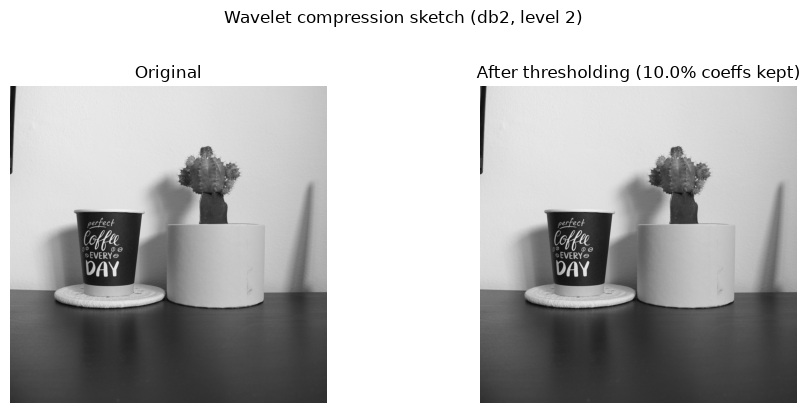

Non-zero coefficients: 10.0% of total
RMSE after reconstruction: 1.83
Fusion uses the same DWT subbands but picks coefficients from two sources instead of discarding them.


In [11]:
demo_img = cv2.imread(str(SAMPLE_IMAGE), cv2.IMREAD_GRAYSCALE).astype(np.float64)
if demo_img is None:
    raise FileNotFoundError(f"Could not load image: {SAMPLE_IMAGE}")
compress_wavelet = "db2"
compress_level = 2

coeffs2 = pywt.wavedec2(demo_img, compress_wavelet, level=compress_level)
flat, coeff_slices, coeff_shapes = pywt.ravel_coeffs(coeffs2)

# Zero smallest 90% of coefficient magnitudes (aggressive demo)
threshold = np.percentile(np.abs(flat), 90)
flat_sparse = np.where(np.abs(flat) < threshold, 0, flat)
nonzero_frac = np.count_nonzero(flat_sparse) / len(flat_sparse)

coeffs_sparse = pywt.unravel_coeffs(
    flat_sparse, coeff_slices, coeff_shapes, output_format="wavedec2"
)
img_compressed = pywt.waverec2(coeffs_sparse, compress_wavelet)
img_compressed = img_compressed[: demo_img.shape[0], : demo_img.shape[1]]

rmse = np.sqrt(np.mean((demo_img - img_compressed) ** 2))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(demo_img, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(np.clip(img_compressed, 0, 255), cmap="gray")
axes[1].set_title(f"After thresholding ({nonzero_frac:.1%} coeffs kept)")
axes[1].axis("off")
plt.suptitle(f"Wavelet compression sketch ({compress_wavelet}, level {compress_level})", y=1.02)
plt.tight_layout()
plt.show()

print(f"Non-zero coefficients: {nonzero_frac:.1%} of total")
print(f"RMSE after reconstruction: {rmse:.2f}")
print("Fusion uses the same DWT subbands but picks coefficients from two sources instead of discarding them.")

## 8. Summary

| Method | Best for | Time info? | Frequency info? |
|--------|----------|------------|----------------|
| **FFT** | Stationary signals | No | Yes (global) |
| **STFT** | Uniform resolution OK | Yes | Yes (fixed window) |
| **CWT** | Transients, multi-scale events | Yes | Yes (adaptive window) |
| **DWT** | Efficient decomposition, images | Yes (localized coeffs) | Yes (dyadic bands) |

**Compression (Section 7B–7C):** DWT analysis (filter + decimation) -> sparse coefficients -> quantize/encode; synthesis (interpolation + filters) reconstructs the signal. Image fusion reuses the same subbands but **merges** two sources instead of discarding coefficients.

**Key insight (Wikipedia principle):** Wavelets are localized in time *and* frequency because scaling changes the effective window length ($\Delta t$) while translation moves it along the signal — satisfying $\Delta t \cdot \Delta\omega \geq \frac{1}{2}$ with **adaptive** resolution per frequency band.

**In this repository:**
- `DCT based image fusion/Code/DCT - based Image Fusion.py` — `MDWT` / `IMDWT` and DWT fusion baseline (`db1`, `db2`, `sym4`)
- `README.md` — Project 2, DWT Baseline section